# **Notebook 2** - Inspecting & Processing Seismic Data

### MVP1 goals: Data inspection, preprocessing, visualizations

This notebook continues the cloud-based seismic workflow started in **Notebook 1**. In **Notebook 1**, we discovered an earthquake event, selected stations, checked waveform availability, and saved reusable event and station metadata. In this notebook, we will use those saved products to retrieve waveform data, inspect waveform quality, apply basic preprocessing steps, and evaluate whether the processed waveform is ready for analysis.

The main workflow in this notebook is:

```
saved event and station metadata
    → waveform streaming
    → waveform inspection
    → preprocessing
    → quality control
    → analysis-ready waveform
```
##### **Why this workflow is useful**

Raw seismic waveforms are not automatically analysis-ready. A waveform downloaded from a data service may contain multiple trace segments, timing gaps or overlaps, instrument effects, raw digital counts, background noise, or frequency content that is not useful for the scientific question.

Before interpreting the signal, we need to inspect the waveform and apply a careful sequence of preprocessing steps. This notebook shows how to move from raw downloaded waveform data toward a cleaner and more standardized waveform that can support later analysis.

GeoLab is useful for this stage because it lets you test preprocessing choices interactively in the same cloud environment where data discovery and retrieval were performed. Instead of repeatedly downloading data to a local machine, you can explore waveform quality, adjust processing parameters, and prepare a reusable processing recipe that can later be applied to a larger dataset.

##### **What you will accomplish**

By the end of this notebook, you will have:

1. loaded the event and station metadata saved from Notebook 1;
2. retrieved waveform data for selected stations using ObsPy;
3. inspected waveform streams for multiple traces, gaps, and overlaps;
4. visualized raw waveform data for quality control;
5. trimmed the waveform around the signal of interest;
6. removed the instrument response to convert raw counts into physical ground-motion units;
7. inspected the frequency content of the waveform using a spectrogram;
8. applied a filter to reduce unwanted noise; and
9. compared unfiltered and filtered waveforms before treating the result as analysis-ready.

##### **Prerequisites**

Before starting this notebook, you should have:

- access to EarthScope GeoLab and a running JupyterLab session;
- basic familiarity with Python;
- basic familiarity with seismic data processing including `obspy`;
- a GeoLab environment with the following Python packages available: `obspy`, `pandas`, `matplotlib`, `cartopy`, and `json`;

You should complete **Notebook 1 — Discovering and Retrieving Seismic Data** before starting this notebook.

**Notebook 2** depends on files created in Notebook 1, including:
```
station_inventory.xml
station_dataframe.csv
event_selection.json
```
These files provide the station inventory, filtered station table, event time, waveform time window, and target channel used in this notebook.

##### **Recommended GeoLab compute resources**
- **Image**: Use the course-provided GeoLab image that includes the seismic and scientific Python stack, including obspy, pandas, matplotlib, scipy, and numpy. Replace this sentence with the exact image name shown in your GeoLab deployment.
- **Server size**: A Small server should be sufficient for the default version of this notebook because it works with short waveform windows and a limited number of stations. Use a Medium server if you expand the notebook to many stations, longer waveform windows, repeated filtering tests, or larger waveform-processing experiments.



Raw seismic waveforms are not automatically analysis-ready. When we download a seismogram from a data service, the waveform may contain multiple trace segments, timing gaps or overlaps, raw digital counts, instrument effects, background noise, or frequency content that is not useful for the scientific question we want to ask. Before we can interpret the signal, we need to understand what is inside the waveform and apply a careful sequence of preprocessing steps.

##### **Learning objectives**

After completing this notebook, you will be able to:

1. Inspect ObsPy Stream and Trace objects to identify waveform segmentation, gaps, and overlaps.
2. Apply basic waveform preprocessing steps, including trimming, instrument-response removal, and filtering.
3. Use visualizations such as waveform plots and spectrograms to guide processing decisions.
4. Explain how preprocessing choices help turn raw seismic data into analysis-ready waveform products.

---

**Our first task is to read the metadata table we saved in Notebook 1.**

In [2]:
# first we read the inventory and metadata that we saved in Notebook1_mvp1.ipynb
from obspy import read_inventory
st_inv = read_inventory("station_inventory.xml")

import pandas as pd
st_df = pd.read_csv("station_dataframe.csv")

import json
from obspy import UTCDateTime

with open("event_selection.json", "r") as f:
    event_selection = json.load(f)

event_time = UTCDateTime(event_selection["event_time"])
t1 = UTCDateTime(event_selection["start_time"])
t2 = UTCDateTime(event_selection["end_time"])
target_channel = event_selection["target_channel"]

st_df


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available
0,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True
1,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True
2,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True
3,UW,ERW,1997-12-01T00:00:00.000000Z,48.453827,-122.626121,387.0,HNZ,200.0,True
4,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True
5,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True
6,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True
7,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True
8,UW,QCDG,2011-11-16T00:00:00.000000Z,48.100020,-122.586960,52.2,HNZ,200.0,True
9,UW,QCEN,2012-06-14T00:00:00.000000Z,46.716350,-122.961900,55.4,HNZ,200.0,True


**Connection to EarthScope Client**

In [7]:
from obspy.clients.fdsn import Client
client = Client("https://service.earthscope.org")
client

FDSN Webservice Client (base url: https://service.earthscope.org)
Available Services: 'dataselect' (v1.1.65), 'station' (v1.1.54)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.

## **1. Data Inspection**

#### **1.1 Waveform inspection--Gaps/Overlaps**


When waveform data are requested using ObsPy, the returned object is a `Stream`. A `Stream` is a container that can hold one or more `Trace` objects. In many simple cases, a request for one station, one channel, and one time window returns a single continuous `Trace`. However, it is also common for the returned `Stream` to contain multiple `Trace` objects.

Multiple traces inside one `Stream` do not automatically mean that something is wrong with the data. They simply indicate that the waveform was returned as separate segments. These segments may represent truly discontinuous data, but they may also be perfectly continuous in time and only separated internally by the data service.

There are several possible reasons why a single waveform request may return multiple traces:

- the waveform contains a real data gap,
- two waveform segments overlap in time,
- the waveform is split into adjacent but continuous time segments,
- there is a small timing break between packets,
- or the data service stores and returns the waveform in multiple pieces.

Gaps can result from loss of power at the recording station or interruptions with the data transfer. For data overlap, clock drifts and corrections can be one of the reason.

A `Stream` with more than one trace may still have no actual gaps or overlaps. To determine whether the trace segments are truly discontinuous, we should use ObsPy’s built-in `get_gaps()` method.

The `get_gaps()` method checks the timing relationship between adjacent traces in the `Stream`. It reports both gaps and overlaps. A positive time difference indicates a gap, while a negative time difference indicates an overlap. If `get_gaps()` returns an empty list, then ObsPy did not detect any gaps or overlaps, even if the `Stream` contains multiple traces.

In the code below, we loop through each station in the dataframe, request waveform data for the selected time window, and then inspect the returned `Stream`. For each station, we print the number of traces retrieved and check whether ObsPy detects any gaps or overlaps. This allows us to distinguish between waveforms that are merely split into multiple continuous segments and waveforms that contain actual timing problems.

This step is useful before merging, plotting, or applying further processing. If no gaps or overlaps are detected, the traces can usually be merged safely. If gaps or overlaps are detected, the waveform should be inspected more carefully before deciding how to handle missing or duplicated data.

In [ ]:
# Retrieve waveform data for each station in the DataFrame and store information data gaps
gaps_info = []  # Initialize an empty list to store gap information
for i in range(len(st_df)):

    # 1. go through each row in the DataFrame
    row_number = i          

    # 2. Retrieve the station and network codes from the DataFrame
    station = st_df.iloc[row_number].station
    network = st_df.iloc[row_number].network
    
    # 3. Retrieve the waveform data for the specified station and channel
    st = client.get_waveforms(
        network=network,
        station=station,
        location="*",
        channel="HNZ",
        starttime=t1,
        endtime=t2
    )

    # 4. Sort the traces in the stream by start time
    st.sort()                   

    # 5. Print statement if more than one trace is retrieved for the station
    if len(st) > 1:
        print(f"\nStation {station} ({network})")
        print(f"Retrieved {len(st)} trace(s)")

        for j, tr in enumerate(st):
            print(
                f"  Trace {j+1}: {tr.id}, "                     # 5.1 Print the trace ID
                f"{tr.stats.starttime} to {tr.stats.endtime}, " # 5.2 Print the start and end times of the trace
                f"npts={tr.stats.npts}, "                       # 5.3 Print the number of points in the trace
                f"dt={tr.stats.delta}"                          # 5.4 Print the sample interval of the trace
            )

    # 6. Check for gaps in the stream
    gaps = st.get_gaps()
    if not gaps:
        print("No gaps or overlaps detected.")
        gaps_info.append(False) # Append False to the gaps list if no gaps are detected
    else:
        print("Gaps/overlaps detected:")
        gaps_info.append(True) # Append True to the gaps list if gaps are detected
        for gap in gaps:
            print(gap)

st_df["gaps_detected"] = gaps_info  # Add the gaps information to the DataFrame
st_df

In the next code snippet you can plot seismic traces using information from the station dataframe for visual inspection. You should at least visualize the station for which you received mutiple traces to get a better idea of the data segmentation.

Retrieved 2 traces for station NLWA (US)


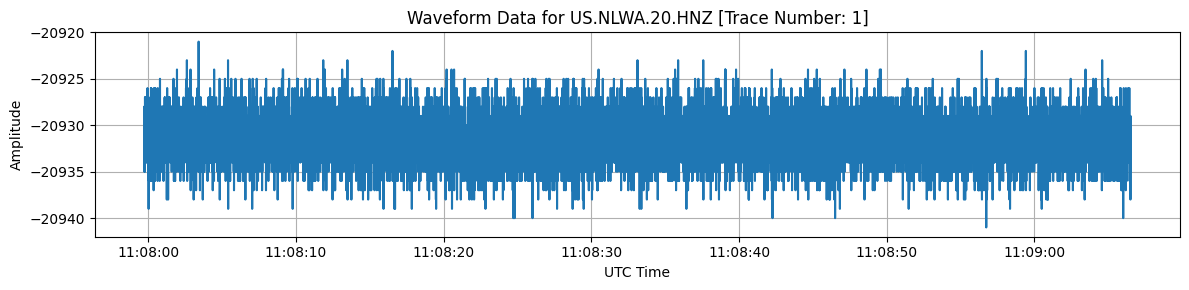

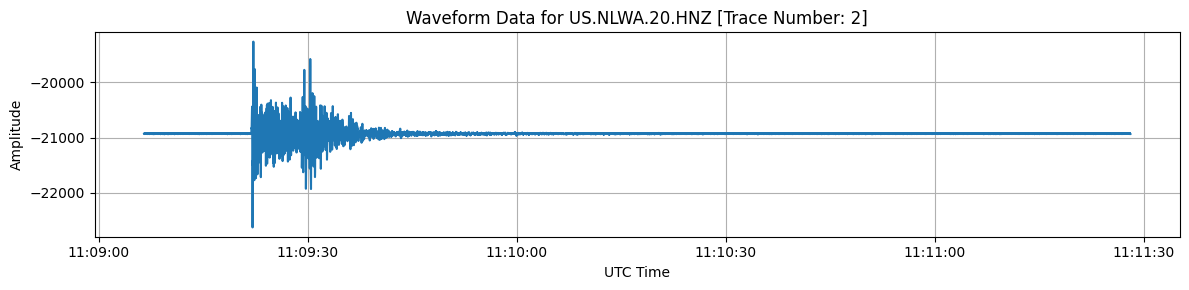

In [32]:
row_number = 0 # You can change this to any row number you want to retrieve

# Retrieve waveform data for a specific station and channel
st = client.get_waveforms(network=df.iloc[row_number].network, 
                            station=df.iloc[row_number].station, location="*", 
                            channel='HNZ', starttime=t1, endtime=t2)

print(f"Retrieved {len(st)} traces for station {df.iloc[row_number].station} ({df.iloc[row_number].network})")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tr_no = 0
for tr in st:
    tr_no += 1 # Count the trace number in the stream

    # Convert ObsPy UTCDateTime values to Python datetime objects
    # Convert each sample time to UTC datetime
    utc_times = [
        (tr.stats.starttime + i * tr.stats.delta).datetime
        for i in range(tr.stats.npts)
    ]
    
    plt.figure(figsize=(12, 3))
    plt.plot(utc_times, tr.data)
    plt.title(f"Waveform Data for {tr.id} [Trace Number: {tr_no}]")
    plt.xlabel("UTC Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.grid(True)
    plt.show()

In cases of multiple `Trace` objects inside a single `Stream` object, the traces can be combined using ObsPy's `merge()` method. If there are no gaps, you can put `fill_value = "None"`. But if there are gaps in the data, you should use `fill_value = "Interpolate"`.

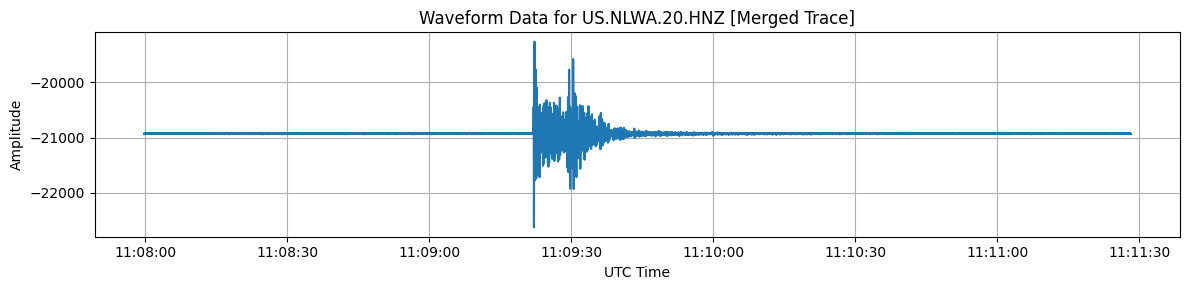

In [31]:
st.merge(method=1, fill_value="None") # Merge the traces in the stream
tr = st[0] 
utc_times = [
    (tr.stats.starttime + i * tr.stats.delta).datetime
    for i in range(tr.stats.npts)
]
plt.figure(figsize=(12, 3))
plt.plot(utc_times, tr.data)
plt.title(f"Waveform Data for {tr.id} [Merged Trace]")
plt.xlabel("UTC Time")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.grid(True)
plt.show()

## **2. Preprocessing**

#### **2.1 Trim waveform around signal**

After retrieving the complete waveform, the next step is to isolate the portion of the record that contains the signal we want to analyze. In this example, the signal of interest is the earthquake arrival which is visible within the longer waveform window.

The original waveform request usually includes extra time before and after the event. This is useful during data retrieval because it gives us enough context to inspect the background noise, identify the signal arrival, and avoid accidentally cutting off important parts of the waveform. However, for later processing steps, we often want to work with a shorter time window centered around the main signal.

Trimming the waveform has several advantages:

- it removes unnecessary pre-event and post-event noise,
- it makes the signal easier to visualize,
- it reduces the amount of data used in later processing,
- and it helps focus the analysis on the part of the waveform that contains useful seismic energy.

 Below, try to modify the `time_pick1` and `time_pick2` to cut the waveform around the signal. These values are measured in seconds after the start of the requested waveform. They define the start and end of the trimmed window.

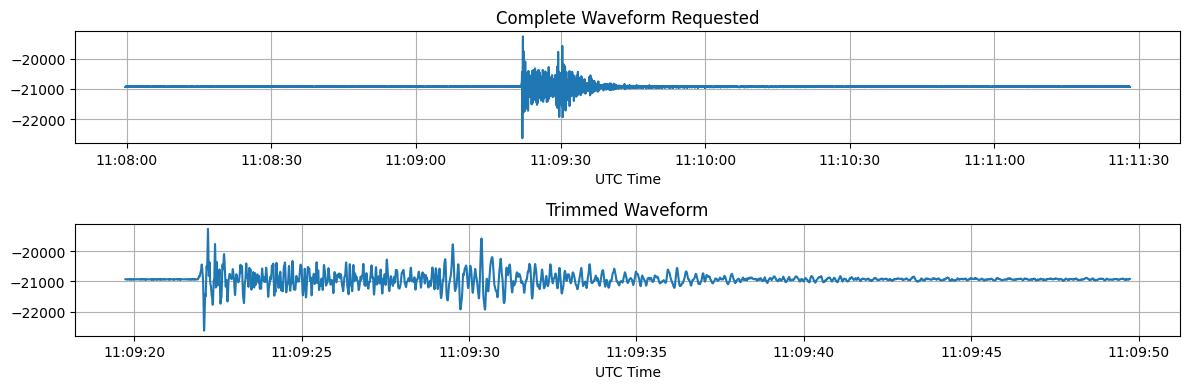

In [ ]:
# 1. Specify the time window for trimming the waveform data
time_pick1 = 80
time_pick2 = 110

# 2.Specify the row number of the station you want to retrieve waveform data for
row_number = 0
st = client.get_waveforms(network=df.iloc[row_number].network, 
                            station=df.iloc[row_number].station, location="*", 
                            channel='HNZ', starttime=t1, endtime=t2)
if len(st)>1: # Check if there are multiple traces in the stream
    st.sort() # Sort the traces in the stream by start time
    st.merge(method=1, fill_value="None") # Merge the traces in the stream (change fill_value for gaps/overlaps)
tr = st[0] # Get the trace from the stream
utc_times = [
    (tr.stats.starttime + i * tr.stats.delta).datetime
    for i in range(tr.stats.npts)
]

# 3. Plot the complete waveform and the trimmed waveform
plt.figure(figsize=(12, 4))
plt.subplot(2,1,1)
plt.plot(utc_times,tr.data)
plt.xlabel("UTC Time")
plt.title("Complete Waveform Requested")
plt.grid()

tr_trim = tr.copy()  # Create a copy of the trace to trim
tr_trim.trim(starttime=tr.stats.starttime+time_pick1, endtime=tr.stats.starttime+time_pick2)
utc_times_trim = [
    (tr_trim.stats.starttime + i * tr_trim.stats.delta).datetime
    for i in range(tr_trim.stats.npts)
]
plt.subplot(2,1,2)
plt.plot(utc_times_trim, tr_trim.data)
plt.xlabel("UTC Time")
plt.title("Trimmed Waveform")
plt.grid()

plt.tight_layout()

#### **2.2 Deconvolve instrument response**

The waveform plotted in the previous section is still in **raw digital counts**. These counts are the values recorded by the seismometer and digitizer, but they are not yet physical ground-motion units such as displacement, velocity, or acceleration.

A seismic instrument does not measure ground motion in a perfectly direct way. When the ground moves, the sensor and recording system transform that motion through the instrument’s mechanical and electronic response. The result is a digital waveform whose amplitude depends not only on the true ground motion, but also on the sensitivity and frequency response of the instrument.

To convert the waveform from raw counts into physically meaningful units, we need to remove, or **deconvolve**, the instrument response. This correction uses the station metadata stored in the ObsPy `Inventory` object. The inventory contains the information needed to describe how the instrument modifies the incoming ground motion.

Text(0.5, 1.0, 'Waveform After Instrument Response Removal')

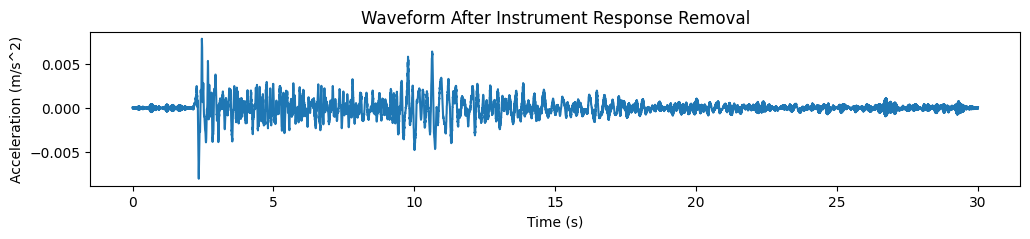

In [33]:
# Apply instrument response
tr_corrected = tr_trim.copy()
tr_corrected.remove_response(inventory=st_inv, output="ACC")  # Specify output units

plt.figure(figsize=(12, 2))
plt.plot(tr_corrected.times(), tr_corrected.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Waveform After Instrument Response Removal")

#### **2.3 Noise reduction**

In this section we will try to reduce noise of the waveform. To reduce this unwanted energy, we first inspect the frequency content of the waveform using a **spectrogram**. A spectrogram shows how signal energy is distributed through both **time** and **frequency**. This is useful because an earthquake signal is not equally strong at all frequencies. Instead, most of the useful seismic energy is usually concentrated within a limited frequency band.

In the output spectrogram below, brighter regions indicate stronger signal energy. By examining where the energy is most prominent, we can choose a filter band that preserves the main earthquake signal while suppressing frequencies dominated by noise. The dashed horizontal lines mark the approximate frequency range selected for filtering.

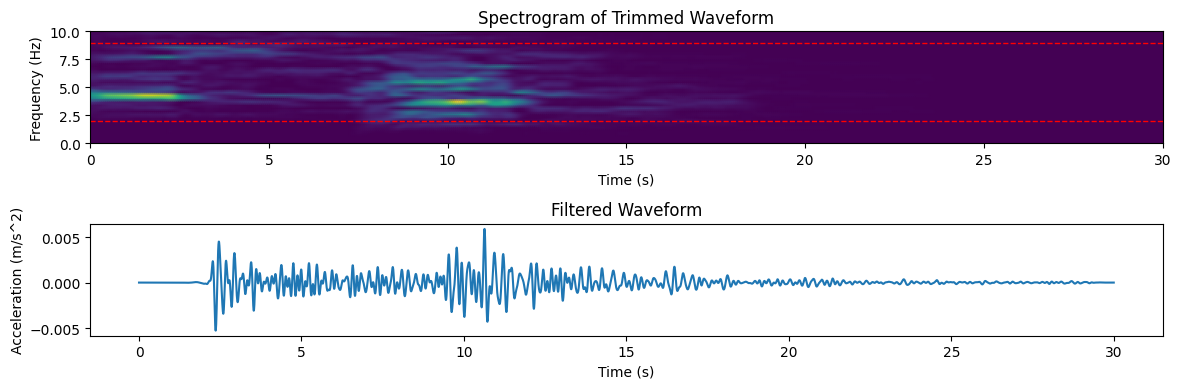

In [35]:
from scipy import signal
import numpy as np

# Sampling rate of the data
fs = tr_corrected.stats.sampling_rate

# Set window size and overlap for the spectrogram
nperseg = 700
noverlap = nperseg - 10

# Compute the spectrogram
f, t_spec, Sxx = signal.spectrogram(tr_corrected.data, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Adjust spectrogram time axis to match slice duration
t_spec = np.linspace(0, tr_corrected.times()[-1], Sxx.shape[1])

plt.figure(figsize=(12, 4))
plt.subplot(2,1,1)
plt.pcolormesh(t_spec, f, np.abs(Sxx), shading='gouraud')
plt.ylim(0, 10)
plt.axhline(y=2, color='red', linestyle='--', linewidth=1)
plt.axhline(y=9, color='red', linestyle='--', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Trimmed Waveform")

tr_filt = tr_corrected.copy()

# Bandpass between 1 and 10 Hz, 4-pole Butterworth, zero-phase
tr_filt.detrend("demean")      # remove DC offset
tr_filt.detrend("linear")      # remove linear trend
tr_filt.taper(max_percentage=0.05, type="hann")   # taper the ends to zero
tr_filt.filter("bandpass",
               freqmin=2.0,
               freqmax=9.0,
               corners=4,
               zerophase=True)

plt.subplot(2,1,2)
plt.plot(tr_filt.times(), tr_filt.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Filtered Waveform")
plt.tight_layout()

#### **2.4 Stage analysis ready formats**

At this point, we have the filtered version of the waveform. Before treating it as analysis-ready, we should compare the waveform **before** and **after** filtering. This is an important quality-control step because filtering should reduce unwanted noise without distorting the earthquake signal that we want to study.

As we compare the unfiltered and filtered waveforms, we need to ask ourselves:
- Does the filtered waveform look cleaner than the original waveform?
- Has low-frequency drift or high-frequency noise been reduced?
- Is the main earthquake signal still preserved?
- Are the arrival time and overall waveform shape still reasonable?
- Did the filter remove anything that may be scientifically useful?
- Did the filter introduce any artificial ringing or distortion?

If the filtered waveform improves signal clarity while preserving the main arrival and waveform shape, then we can treat this processing sequence as a good candidate for producing an **analysis-ready waveform**. This means the waveform has been cleaned, standardized, documented, and stored in a way that makes it ready for repeated scientific use.

In a small example like this notebook, we can manually inspect one waveform, choose preprocessing parameters, and then apply them to a few more stations. However, for a large seismic dataset, this approach becomes more challenging. Downloading, trimming, correcting, filtering, and saving each waveform one by one can become slow and computationally expensive.

There are two general ways to move from single-waveform preprocessing to dataset-scale analysis.

<u>**Pathway 1:** Process every waveform individually</u>

In this workflow, each waveform is downloaded, preprocessed, inspected, and saved individually. This is simple and transparent, but it can become inefficient for large datasets. Repeated waveform downloads and repeated local processing can stress the local workstation by increasing pressure on RAM, disk storage, disk cache, CPU time, and network bandwidth.

<u>**Pathway 2:** Explore parameters first, then stage analysis-ready products</u>

A more scalable workflow is to first explore a representative subset of waveforms. Once the preprocessing choices are understood, those parameters can be applied consistently across the larger dataset.

>Access waveform subset
    → explore preprocessing parameters
    → choose stable processing settings
    → apply settings to larger dataset
    → save analysis-ready waveform products

This second pathway is often more efficient because the expensive exploration step is done on a smaller subset of data. Once the processing recipe is selected, the same workflow can be applied at scale.

For small and medium-sized datasets, the traditional local workflow may be sufficient. For large-scale seismic datasets, however, repeatedly downloading and processing raw data on a local machine can become cumbersome. In that case, a cloud-optimized or GeoLab-based workflow can make the process faster, more reproducible, and easier to scale.

| Workflow step | Traditional Workflow | GeoLab based Workflow |
| :---: | :---: | :---: |
| Data access | Need to download raw data | Cloud-optimized access to raw data & save processed waveform of small or intermediate scale |
| Data storage | Save processed waveforms on local machine | Save processed waveform of small or intermediate scale in temporary cloud storage |
| Computational load | Large datasets can stress local RAM, disk storage, disk cache, CPU & network bandwidth | Efficient data access with negligible stress on computational resources |
| Repeated experiements | Changing parameters may require repeated downloads and local reprocessing | Parameters can be tested efficiently on subsets before scaling up |

Below, we will apply the preprocessing recipe to every station in the station dataframe one-by-one to stage analysis ready formats. For that we have create a reusable function that will output the filtered waveform.

In [ ]:
def process_and_save_filtered_waveform(station_dataframe):
    